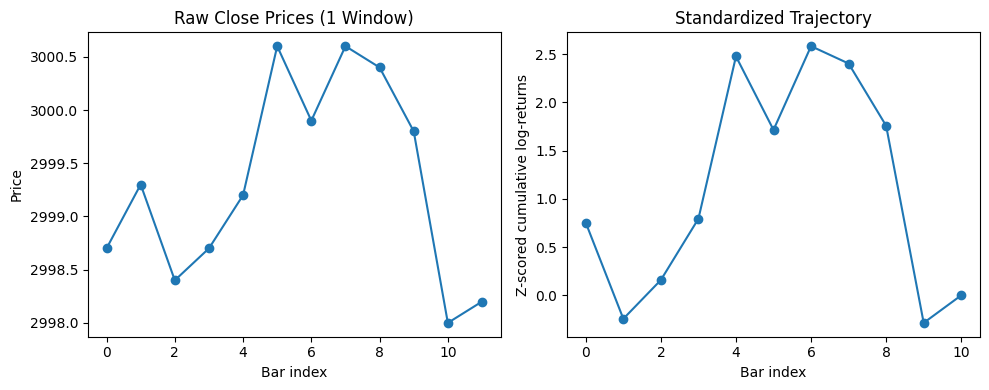

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Load Excel file ----
# ⚠️ Change the path below if your file has a different name or folder
file_path = r"/Users/iseo/Documents/GC1.xlsx"
df = pd.read_excel(file_path)

# ---- Fix columns ----
# Convert DATE column to datetime
df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True)

# Replace commas with dots in numeric columns and convert to float
for col in ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

# ---- Set index to datetime ----
df.set_index('DATE', inplace=True)

# ---- Example raw window (12 x 5min bars) ----
window = df['CLOSE'].iloc[0:12].values

# Step 1: log-returns
log_returns = np.diff(np.log(window))

# Step 2: Z-score normalization
z_scores = (log_returns - log_returns.mean()) / log_returns.std()

# Step 3: cumulative reconstruction
standardized_path = np.cumsum(z_scores)

# ---- Plot before vs after ----
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(window, marker='o')
plt.title("Raw Close Prices (1 Window)")
plt.xlabel("Bar index")
plt.ylabel("Price")

plt.subplot(1,2,2)
plt.plot(standardized_path, marker='o')
plt.title("Standardized Trajectory")
plt.xlabel("Bar index")
plt.ylabel("Z-scored cumulative log-returns")

plt.tight_layout()
plt.show()

/Users/iseo/Documents/GitHub/Memoire_code/.venv/lib/python3.13/site-packages/tslearn/metrics/dtw_variants.py:1749: SyntaxWarning: invalid escape sequence '\d'
  """Compute the mask (region constraint).


ImportError: Numba needs NumPy 2.2 or less. Got NumPy 2.3.

In [6]:
!pip uninstall dtaidistance tslearn
Y


Found existing installation: dtaidistance 2.3.13
Uninstalling dtaidistance-2.3.13:
  Would remove:
    /Users/iseo/Documents/GitHub/Memoire_code/.venv/lib/python3.13/site-packages/dtaidistance-2.3.13.dist-info/*
    /Users/iseo/Documents/GitHub/Memoire_code/.venv/lib/python3.13/site-packages/dtaidistance/*
Proceed (Y/n)? ^C


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from dtaidistance import dtw
from tslearn.metrics import soft_dtw

# Example synthetic windows (similar shape, shifted in time)
x = np.array([0,1,2,3,4,3,2,1,0])
y = np.array([1,2,3,4,3,2,1,0,0])  # shifted pattern

# Euclidean distance
d_euc = np.linalg.norm(x - y)

# DTW distance
d_dtw = dtw.distance(x, y)

# Soft-DTW distance
d_soft = soft_dtw(x.reshape(-1,1), y.reshape(-1,1), gamma=1.0)

print("Euclidean:", d_euc)
print("DTW:", d_dtw)
print("Soft-DTW:", d_soft)

# Plot
plt.figure(figsize=(8,4))
plt.plot(x, marker='o', label="Trajectory X")
plt.plot(y, marker='x', label="Trajectory Y")
plt.title("Two standardized trajectories (shifted)")
plt.legend()
plt.show()

ImportError: Numba needs NumPy 2.2 or less. Got NumPy 2.3.

Euclidean: 2.8284271247461903
DTW: 1.0


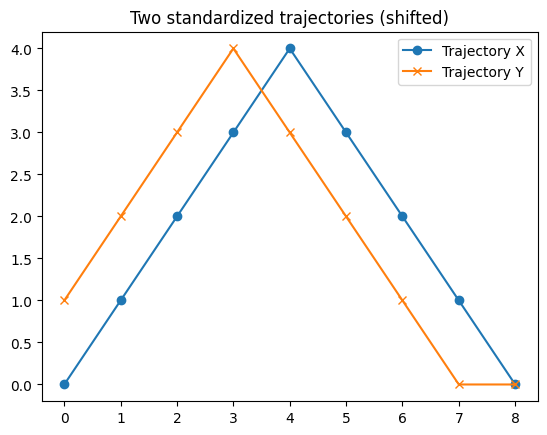

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

def dtw_distance(x, y):
    n, m = len(x), len(y)
    cost = cdist(x.reshape(-1,1), y.reshape(-1,1), metric='sqeuclidean')
    dp = np.zeros((n+1, m+1)) + np.inf
    dp[0,0] = 0

    for i in range(1, n+1):
        for j in range(1, m+1):
            dp[i,j] = cost[i-1,j-1] + min(dp[i-1,j], dp[i,j-1], dp[i-1,j-1])
    return np.sqrt(dp[n,m])

# Example synthetic windows
x = np.array([0,1,2,3,4,3,2,1,0])
y = np.array([1,2,3,4,3,2,1,0,0])

# Euclidean
d_euc = np.linalg.norm(x - y)

# DTW (custom)
d_dtw = dtw_distance(x, y)

print("Euclidean:", d_euc)
print("DTW:", d_dtw)

plt.plot(x, marker='o', label="Trajectory X")
plt.plot(y, marker='x', label="Trajectory Y")
plt.title("Two standardized trajectories (shifted)")
plt.legend()
plt.show()

Euclidean: 2.8284271247461903
DTW: 1.0
Soft-DTW: -4.0365143184959384


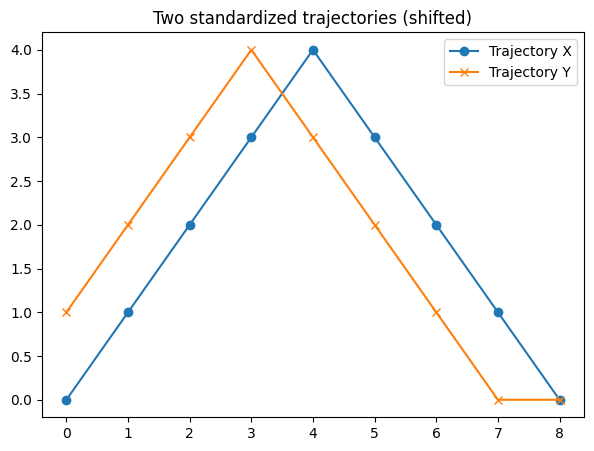

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

# ---- Example synthetic windows (shifted shape) ----
x = np.array([0,1,2,3,4,3,2,1,0])
y = np.array([1,2,3,4,3,2,1,0,0])

# Euclidean distance
d_euc = np.linalg.norm(x - y)

# DTW (classic dynamic programming)
def dtw_distance(a, b):
    n, m = len(a), len(b)
    dp = np.full((n+1, m+1), np.inf)
    dp[0,0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = (a[i-1] - b[j-1])**2
            dp[i,j] = cost + min(dp[i-1,j], dp[i,j-1], dp[i-1,j-1])
    return np.sqrt(dp[n,m])

d_dtw = dtw_distance(x, y)

# Soft-DTW (simplified version with log-sum-exp)
def soft_dtw(a, b, gamma=1.0):
    n, m = len(a), len(b)
    D = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            D[i,j] = (a[i] - b[j])**2
    R = np.full((n+1, m+1), np.inf)
    R[0,0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            r0 = -R[i-1,j-1]/gamma
            r1 = -R[i-1,j]/gamma
            r2 = -R[i,j-1]/gamma
            r = np.array([r0, r1, r2])
            R[i,j] = D[i-1,j-1] - gamma*logsumexp(r)
    return R[n,m]

d_soft = soft_dtw(x, y, gamma=1.0)

print("Euclidean:", d_euc)
print("DTW:", d_dtw)
print("Soft-DTW:", d_soft)

# ---- Plot ----
plt.figure(figsize=(7,5))
plt.plot(x, marker='o', label="Trajectory X")
plt.plot(y, marker='x', label="Trajectory Y")
plt.title("Two standardized trajectories (shifted)")
plt.legend()
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import hdbscan
from scipy.spatial.distance import squareform

# ---- Example distance matrix (symmetric, NxN) ----
# Suppose we have M trajectories standardized (x1,...,xM)
# For simplicity here we simulate with random distances
M = 10
rng = np.random.default_rng(42)
D = rng.random((M, M))
D = (D + D.T) / 2  # make symmetric
np.fill_diagonal(D, 0)

# ---- Run HDBSCAN ----
clusterer = hdbscan.HDBSCAN(min_cluster_size=3, metric='precomputed')
labels = clusterer.fit_predict(D)

print("Cluster labels:", labels)

# ---- Plot heatmap of distances ----
plt.imshow(D, cmap='viridis')
plt.colorbar(label="Distance")
plt.title("Pairwise Distance Matrix")
plt.show()

ModuleNotFoundError: No module named 'hdbscan'

Windows: 10404    Feature dim: 11
Embedded dim: 3
K-means inertia: 74719.61496628501
Transition matrix P:
 [[0.674 0.018 0.308]
 [0.02  0.7   0.28 ]
 [0.194 0.221 0.585]]
Stationary distribution pi: [0.267 0.32  0.414]


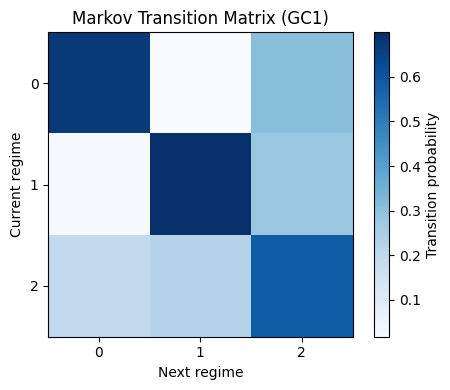

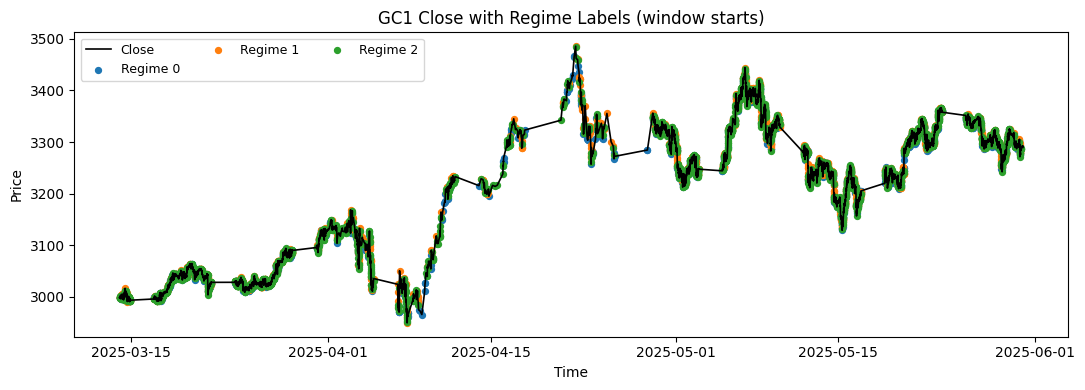

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) LOAD & CLEAN GC1 EXCEL
# =========================
file_path = r"/Users/Iseo/Documents/GC1.xlsx"  # <-- adapte le chemin
df = pd.read_excel(file_path)

# Harmonise noms et types
df.columns = [c.strip().upper() for c in df.columns]
df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True)

for col in ['OPEN','HIGH','LOW','CLOSE','VOLUME']:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

df = df.set_index('DATE').sort_index()

# ==========================================
# 2) WINDOWING + TRANSFORMATION (morphology)
#    (log-returns -> z-score in-window -> cum)
# ==========================================
def standardize_window(close_values):
    """close_values: array of shape (L,)"""
    log_returns = np.diff(np.log(close_values))           # length L-1
    mu = log_returns.mean()
    sd = log_returns.std(ddof=0)
    if sd == 0:  # fenêtre plate : évite division par 0
        z = np.zeros_like(log_returns)
    else:
        z = (log_returns - mu) / sd
    standardized_path = np.cumsum(z)                      # length L-1
    return standardized_path

def build_windows(series, L=12, stride=1):
    X = []               # features (standardized paths)
    t_index = []         # timestamps (start of each window)
    close = series.values
    idx = series.index
    for start in range(0, len(series) - L + 1, stride):
        w_close = close[start:start+L]
        feat = standardize_window(w_close)               # length L-1
        X.append(feat)
        t_index.append(idx[start])
    X = np.vstack(X) if len(X) else np.empty((0, L-1))
    return X, pd.Index(t_index, name="t0")

L = 12         # 12x5min ≈ 60 minutes (à adapter)
STRIDE = 1
X, t0_index = build_windows(df['CLOSE'], L=L, stride=STRIDE)
print("Windows:", X.shape[0], "   Feature dim:", X.shape[1])

# =========================
# 3) PCA by SVD (no sklearn)
# =========================
def pca_svd(X, n_components=3):
    Xc = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    components = Vt[:n_components]
    X_emb = Xc @ components.T
    return X_emb, components, X.mean(axis=0)

X_emb, comps, mean_feat = pca_svd(X, n_components=3)
print("Embedded dim:", X_emb.shape[1])

# ======================
# 4) K-MEANS (from scratch)
# ======================
def kmeans_numpy(X, K=3, n_init=5, max_iter=100, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    best_inertia = np.inf
    best = None

    for _ in range(n_init):
        # init++ simplifiée : échantillonne aléatoire
        centers = X[rng.choice(len(X), K, replace=False)].copy()

        for _ in range(max_iter):
            # assign
            d2 = ((X[:, None, :] - centers[None, :, :])**2).sum(axis=2)
            labels = d2.argmin(axis=1)
            # update
            new_centers = np.array([X[labels==k].mean(axis=0) if np.any(labels==k)
                                    else centers[k] for k in range(K)])
            if np.allclose(new_centers, centers):
                centers = new_centers
                break
            centers = new_centers

        inertia = ((X - centers[labels])**2).sum()
        if inertia < best_inertia:
            best_inertia = inertia
            best = (labels.copy(), centers.copy())

    return best[0], best[1], best_inertia

K = 3  # nombre de régimes (change à 4/5 si besoin)
labels, centers, inertia = kmeans_numpy(X_emb, K=K, n_init=8, max_iter=200)
print("K-means inertia:", inertia)

# =====================================================
# 5) BUILD MARKOV TRANSITION MATRIX + STATIONARY DISTR.
# =====================================================
def transition_matrix(labels, K):
    P = np.zeros((K, K), dtype=float)
    for a, b in zip(labels[:-1], labels[1:]):
        P[a, b] += 1.0
    # normalisation par ligne (évite NaN si ligne nulle)
    row_sums = P.sum(axis=1, keepdims=True)
    row_sums[row_sums==0] = 1.0
    P = P / row_sums
    return P

P = transition_matrix(labels, K)

# Stationary distribution (left eigenvector for eigenvalue 1)
eigvals, eigvecs = np.linalg.eig(P.T)
i1 = np.argmin(np.abs(eigvals - 1.0))
pi = np.real(eigvecs[:, i1])
pi = pi / pi.sum()
pi = np.maximum(pi, 0); pi = pi / pi.sum()  # sécurité num.

print("Transition matrix P:\n", np.round(P, 3))
print("Stationary distribution pi:", np.round(pi, 3))

# =========================
# 6) PLOTS FOR THE APPENDIX
# =========================

# (a) Heatmap P
plt.figure(figsize=(5,4))
plt.imshow(P, cmap="Blues", interpolation="nearest")
plt.colorbar(label="Transition probability")
plt.title("Markov Transition Matrix (GC1)")
plt.xlabel("Next regime")
plt.ylabel("Current regime")
plt.xticks(range(K)); plt.yticks(range(K))
plt.tight_layout()
plt.show()

# (b) Price + regime markers (start of each window)
plt.figure(figsize=(11,4))
plt.plot(df.index, df['CLOSE'], color='black', linewidth=1.2, label='Close')
for k in range(K):
    t_k = t0_index[labels==k]
    plt.scatter(t_k, df.loc[t_k, 'CLOSE'], s=18, label=f"Regime {k}")
plt.title("GC1 Close with Regime Labels (window starts)")
plt.xlabel("Time"); plt.ylabel("Price")
plt.legend(ncol=K, fontsize=9)
plt.tight_layout()
plt.show()

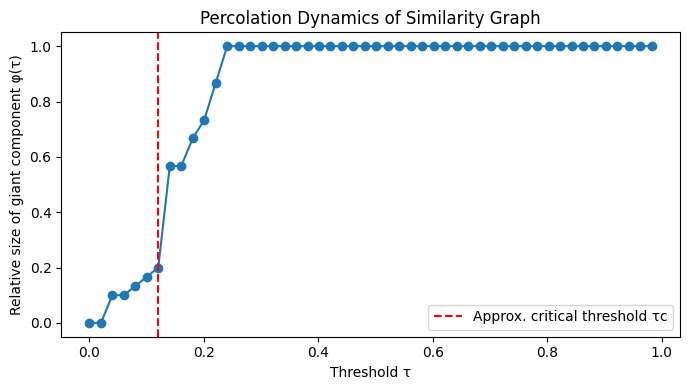

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ---- Example distance matrix D from Appendix C ----
# (here: we reuse a small random matrix for illustration)
M = 30
rng = np.random.default_rng(42)
D = rng.random((M, M))
D = (D + D.T) / 2
np.fill_diagonal(D, 0)

# ---- Percolation: vary threshold tau ----
taus = np.linspace(0, D.max(), 50)
giant_sizes = []

for tau in taus:
    G = nx.Graph()
    for i in range(M):
        for j in range(i+1, M):
            if D[i,j] <= tau:
                G.add_edge(i, j)
    if len(G) > 0:
        giant = max(nx.connected_components(G), key=len)
        phi = len(giant)/M
    else:
        phi = 0
    giant_sizes.append(phi)

# ---- Plot percolation curve ----
plt.figure(figsize=(7,4))
plt.plot(taus, giant_sizes, marker='o')
plt.axvline(x=taus[np.argmax(np.diff(giant_sizes))], color='red', linestyle='--',
            label="Approx. critical threshold τc")
plt.xlabel("Threshold τ")
plt.ylabel("Relative size of giant component φ(τ)")
plt.title("Percolation Dynamics of Similarity Graph")
plt.legend()
plt.tight_layout()
plt.show()